<a href="https://colab.research.google.com/github/GIRIAYUSH/playing-with-anns/blob/main/notebooks/M1_tensors_autograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Cloning the Repo

In [73]:
import os
os.chdir('/content/playing-with-anns')

!git pull origin main --rebase

From https://github.com/GIRIAYUSH/playing-with-anns
 * branch            main       -> FETCH_HEAD
Successfully rebased and updated refs/heads/main.


In [74]:
from google.colab import userdata
import os

TOKEN    = userdata.get('GITHUB_TOEKN')
USERNAME = 'GIRIAYUSH'
REPO     = 'playing-with-anns'
REPO_URL = f'https://{TOKEN}@github.com/{USERNAME}/{REPO}.git'
REPO_PATH = f'/content/{REPO}'

if not os.path.exists(REPO_PATH):
    !git clone {REPO_URL} {REPO_PATH}
else:
    os.chdir(REPO_PATH)
    # Always reset remote to token URL before pulling
    !git remote set-url origin {REPO_URL}
    !git pull origin main

os.chdir(REPO_PATH)
!git remote set-url origin {REPO_URL}   # ensure push also uses token
!git config user.email "giri.ayush2024@gmail.com"
!git config user.name "Ayush Giri"

print(f"📁 Now in: {os.getcwd()}")
!ls

From https://github.com/GIRIAYUSH/playing-with-anns
 * branch            main       -> FETCH_HEAD
Already up to date.
📁 Now in: /content/playing-with-anns
notebooks  outputs  readme.md  utils


### M1 Tensors and Autograd

> *"Everything in deep learning is a tensor. Everything."*

The foundation of all future modules. Before writing a single neural network,
you need to understand the data structure that powers it.

**What you'll implement:**
- Creating tensors from scratch — different `dtype`, `shape`, and `device`
- Moving tensors to GPU (`cuda`) and back
- Arithmetic operations: element-wise, matrix multiply (`@`), broadcasting
- Enabling gradient tracking with `requires_grad=True`
- Visualizing the computation graph that PyTorch builds silently

*Core concept:** PyTorch doesn't just do math — it records *how* it did
the math so it can reverse it later. That recording is the computation graph,
and it's the secret engine behind backprop.

In [75]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"Pytorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

Pytorch version: 2.10.0+cu128
GPU available: True


### TENSORS VS YOUR NORMAL ARRAYS
## Array vs Tensor

| Array | Tensor |
|---|---|
| A collection of elements arranged in rows, columns, or higher dimensions. | A generalized mathematical structure that extends arrays to multiple dimensions with additional algebraic properties. |
| Mainly used for storing and processing data. | Used in deep learning, physics, and scientific computing for mathematical operations. |
| Usually supports basic indexing and arithmetic operations. | Supports advanced operations like gradients, transformations, and GPU acceleration. |
| Example: NumPy array. | Example: PyTorch tensor or TensorFlow tensor. |
| Arrays are generally limited to data representation. | Tensors are optimized for numerical computation and machine learning. |

### Creating Tensors
A tensor is just an n-dimensional array but one that knows how to compute gradients. Let's create them different ways and understand what `dtype` and `shape` actually mean

In [76]:
t1 = torch.tensor([1,2,3])
print(f"From list: {t1} | dtype: {t1.dtype} | shape {t1.shape}")

#float tensor
t2 = torch.tensor([1.0,2.0,3.0], dtype=torch.float32)
print(f"Float tensor : {t2} | dtype: {t2.dtype} | shape {t2.shape}")

#double precision tensor
t3 = torch.tensor([1.0,2.0,3.0],dtype=torch.float64)
print(f"Float64:        {t3} | dtype: {t3.dtype} | shape {t3.shape}")

From list: tensor([1, 2, 3]) | dtype: torch.int64 | shape torch.Size([3])
Float tensor : tensor([1., 2., 3.]) | dtype: torch.float32 | shape torch.Size([3])
Float64:        tensor([1., 2., 3.], dtype=torch.float64) | dtype: torch.float64 | shape torch.Size([3])


#### Creating random tensors

In [77]:
#zero-tensor
zeros=torch.zeros(3,4)
ones=torch.ones(3,4)
#normally distrubited
random_tensors= torch.randn(3,4)

print(f"\nZero tensors: {zeros.shape}")
print(f"Ones tensors: {zeros.shape}")
print(f"\nNormally distributed random tensors:\n {random_tensors}")


Zero tensors: torch.Size([3, 4])
Ones tensors: torch.Size([3, 4])

Normally distributed random tensors:
 tensor([[ 1.1169,  0.1633, -0.2616,  0.5175],
        [-0.3951, -0.5223, -0.6336,  1.5982],
        [-0.5938, -1.2789,  0.5502, -1.7185]])


### Moving Tensors to GPU

In deep learning, computation happens on the GPU for speed. We need to move tensors to the GPU using `.to('cuda')` and back with `.to('cpu')



In [78]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

t = torch.tensor([1.0,2.0,3.0])
print(f"\nBefore: {t.device}")

t.to(device)
print(f"After : {t.device}")

t=t.to('cpu')
print(f"Back: {t.device}")


Before: cpu
After : cpu
Back: cpu


---
#### 3. Arithmetic Operations

Tensors support element-wise math, matrix multiplication, and broadcasting.
These three operations are the backbone of every neural network layer.

In [79]:
a = torch.tensor([1.0,2.0,3.0])
b= torch.tensor([4.0,5.0,6.0])

print(f"Element Wise")
print(f"a + b  = {a + b}")
print(f"a * b  = {a * b}")
print(f"a ** 2 = {a ** 2}")

#Matrix Multiplication core of every linear layer
print("Matrix Multiplication")
W=torch.randn(3,4) #sample weight matrix
x= torch.rand(4) #input vector notice the dimension

out = W @ x
print(f"W shape: {W.shape}")
print(f"x shape: {x.shape}")
print(f"W @ x   = {out}  | shape: {out.shape}")

# Broadcasting — smaller tensor stretches to match larger one
print("Broadcasting")
matrix = torch.ones(3, 4)
bias = torch.tensor([1.0, 2.0, 3.0, 4.0])
print(f"matrix + bias =\n{matrix + bias}")


Element Wise
a + b  = tensor([5., 7., 9.])
a * b  = tensor([ 4., 10., 18.])
a ** 2 = tensor([1., 4., 9.])
Matrix Multiplication
W shape: torch.Size([3, 4])
x shape: torch.Size([4])
W @ x   = tensor([2.4607, 0.6036, 1.1064])  | shape: torch.Size([3])
Broadcasting
matrix + bias =
tensor([[2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.]])


#### Gradient Tracking with 'require_grad'
This is where PyTorch becomes magical.

When you set `requires_grad=True`, PyTorch starts recording every operation
on that tensor into a **computation graph**. When you call `.backward()`,
it walks that graph backwards and computes the gradient of the output
with respect to every tracked tensor.

That gradient is stored in `.grad` — and it's exactly what the optimizer
uses to update the weights.

In [80]:
# Simple example: y = x^2, dy/dx = 2x
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

print(f"x     = {x}")
print(f"y     = x^2 = {y}")

# Compute gradients
y.backward()

print(f"\ndy/dx at x=3 → expected: 6.0")
print(f"x.grad        → got:      {x.grad}")

x     = 3.0
y     = x^2 = 9.0

dy/dx at x=3 → expected: 6.0
x.grad        → got:      6.0


In [81]:
# More realistic: z = 3x^2 + 2x + 1, dz/dx = 6x + 2
x = torch.tensor(2.0, requires_grad=True)
z = 3 * x**2 + 2 * x + 1

z.backward()

expected = 6 * 2.0 + 2    # = 14.0
print(f"z = 3x² + 2x + 1  at x=2  →  z = {z.item():.1f}")
print(f"dz/dx = 6x + 2     at x=2  →  expected: {expected}")
print(f"x.grad                     →  got:      {x.grad.item()}")

z = 3x² + 2x + 1  at x=2  →  z = 17.0
dz/dx = 6x + 2     at x=2  →  expected: 14.0
x.grad                     →  got:      14.0


### 5. Visualizing the Computation Graph

Every time you do math on a `requires_grad` tensor, PyTorch silently
builds a graph of operations. Let's make that visible.

Below we'll trace a simple expression and print the `grad_fn`
(the function PyTorch will call during backprop) at each node.

In [82]:
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# Simulating one neuron: output = w*x + b
h = w * x        # multiplication node
y = h + b        # addition node

print("=== Computation Graph (grad_fn at each node) ===")
print(f"x.grad_fn  = {x.grad_fn}   ← leaf node, no grad_fn")
print(f"w.grad_fn  = {w.grad_fn}   ← leaf node, no grad_fn")
print(f"h.grad_fn  = {h.grad_fn}   ← result of multiplication")
print(f"y.grad_fn  = {y.grad_fn}   ← result of addition")

# Now backprop
y.backward()

print("\n=== Gradients after y.backward() ===")
print(f"dy/dw = x = {w.grad.item():.1f}   (expected {x.item():.1f})")
print(f"dy/dx = w = {x.grad.item():.1f}   (expected {w.item():.1f})")
print(f"dy/db = 1 = {b.grad.item():.1f}   (expected 1.0)")

=== Computation Graph (grad_fn at each node) ===
x.grad_fn  = None   ← leaf node, no grad_fn
w.grad_fn  = None   ← leaf node, no grad_fn
h.grad_fn  = <MulBackward0 object at 0x7bdecc3dac50>   ← result of multiplication
y.grad_fn  = <AddBackward0 object at 0x7bdecc3dac50>   ← result of addition

=== Gradients after y.backward() ===
dy/dw = x = 2.0   (expected 2.0)
dy/dx = w = 3.0   (expected 3.0)
dy/db = 1 = 1.0   (expected 1.0)


### 6. Visualizing Gradients

Let's plot how the gradient of a function changes across a range of x values.
This gives the intuition for why gradients tell us which direction to move.

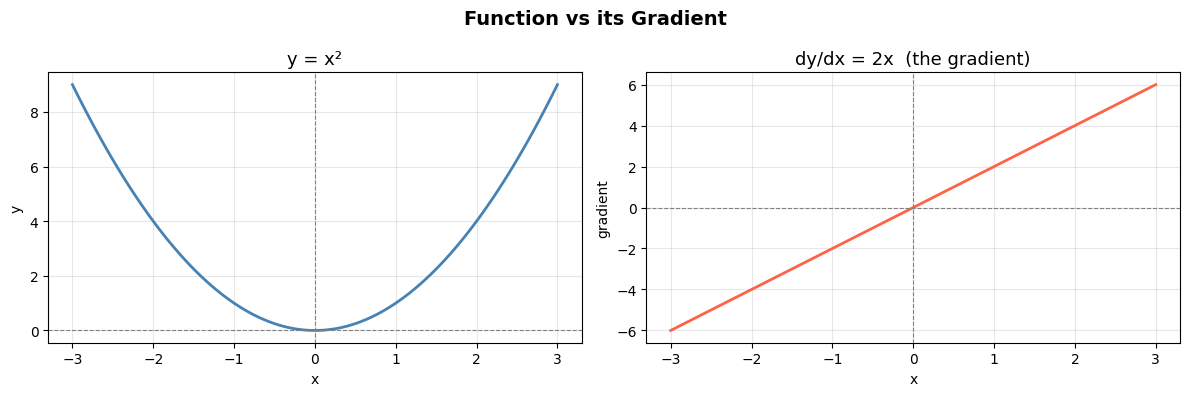

Plot saved to outputs/


In [83]:
# Plot y = x^2 and its gradient dy/dx = 2x side by side

x_vals = torch.linspace(-3, 3, 100, requires_grad=False)
y_vals = x_vals ** 2

# Compute gradients manually for plotting (2x)
grad_vals = 2 * x_vals

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: the function
axes[0].plot(x_vals.numpy(), y_vals.numpy(), color='steelblue', lw=2)
axes[0].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[0].axvline(0, color='gray', lw=0.8, linestyle='--')
axes[0].set_title("y = x²", fontsize=13)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(True, alpha=0.3)

# Right: the gradient
axes[1].plot(x_vals.numpy(), grad_vals.numpy(), color='tomato', lw=2)
axes[1].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[1].axvline(0, color='gray', lw=0.8, linestyle='--')
axes[1].set_title("dy/dx = 2x  (the gradient)", fontsize=13)
axes[1].set_xlabel("x")
axes[1].set_ylabel("gradient")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Function vs its Gradient", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/M1_gradient_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to outputs/")

---
## 7. Key Takeaways

| Concept | What it means |
|---|---|
| `torch.tensor` | The basic data structure — an n-dimensional array |
| `dtype` | The number format — `float32` is the standard for training |
| `requires_grad=True` | Tell PyTorch to track operations for backprop |
| `.backward()` | Walk the computation graph backwards, fill `.grad` |
| `.grad` | The gradient — how much this weight affects the output |
| `grad_fn` | The recorded operation PyTorch will reverse during backprop |

**The big idea:** When you call `.backward()`, PyTorch already knows
exactly what math was done because it recorded every step. It just
runs it in reverse using the chain rule. That's all backprop is.

Next up → **M2: Forward Pass** — we'll use tensors to build
and run an actual neural network layer.

In [85]:
import os
os.chdir('/content/playing-with-anns')

!git add notebooks/M1_tensors_autograd.ipynb
!git commit -m "M1: tensors and autograd complete"
!git push origin main

print("✅ Pushed!")

On branch main
nothing to commit, working tree clean
Everything up-to-date
✅ Pushed!
